# Übung 4 - Pokemon-Analyse

**IEM.DAM2, SS 2026**

Dieses Notebook arbeitet die fünf Teilaufgaben der Übung durch:

1. **Distanzfunktion** - Entwurf einer sinnvollen paarweisen Distanz über den Pokedex.
2. **Clustering** - Anwendung eines Clusteringverfahrens auf dieser Distanz und Parameterwahl per Silhouettenkoeffizient.
3. **Visualisierung** - 2D-Projektion mit tSNE und UMAP, eingefärbt nach Cluster.
4. **Ausreißererkennung** - ungewöhnliche Pokemon mit LOF, Isolation Forest und HDBSCAN-Rauschen markieren.
5. **Diskussion** - Reflexion über Funktionierendes und Verbesserungspotenzial.

Datensatz: `pokedex.csv` (898 Pokemon, sechs Basis-Stats, Größe/Gewicht, 17 One-Hot Type-Spalten, Thumbnails).

## Setup

Imports und ein paar kleine Hilfsfunktionen. `umap-learn` und `hdbscan` sind optional - das Notebook funktioniert auch ohne sie weiter.

In [1]:
import re
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import pairwise_distances, silhouette_score
from sklearn.cluster import AgglomerativeClustering
from sklearn.manifold import TSNE
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor

warnings.filterwarnings("ignore")

OUT = Path("figures")
OUT.mkdir(exist_ok=True)

## 1. Daten laden

`height` und `weight` sind als Strings gespeichert (`"0.7 m"`, `"6.9 kg"`), daher parsen wir die führende Zahl in numerische Spalten. Alles andere ist bereits numerisch oder One-Hot kodiert.

In [2]:
def parse_number(s):
    m = re.search(r"([\d.]+)", str(s))
    return float(m.group(1)) if m else np.nan

df = pd.read_csv("pokedex.csv")
df["height_m"] = df["height"].apply(parse_number)
df["weight_kg"] = df["weight"].apply(parse_number)

STAT_COLS = ["HP", "attack", "defense", "sp. attack", "sp. defense", "speed"]
SIZE_COLS = ["height_m", "weight_kg"]
TYPE_COLS = [c for c in df.columns if c.startswith("type_")]

print(f"{len(df)} Pokemon, {df.shape[1]} Spalten")
print(f"Type-Spalten ({len(TYPE_COLS)}): {[t.replace('type_', '') for t in TYPE_COLS]}")
df.head()

898 Pokemon, 33 Spalten
Type-Spalten (17): ['fire', 'water', 'electric', 'grass', 'ice', 'fighting', 'poison', 'ground', 'flying', 'psychic', 'bug', 'rock', 'ghost', 'dragon', 'dark', 'steel', 'fairy']


,id,name,HP,attack,defense,sp. attack,sp. defense,speed,species,description,...,type_psychic,type_bug,type_rock,type_ghost,type_dragon,type_dark,type_steel,type_fairy,height_m,weight_kg
0,1,Bulbasaur,45,49,49,65,65,45,Seed Pokémon,Bulbasaur can be seen napping in bright sunlig...,...,0,0,0,0,0,0,0,0,0.7,6.9
1,2,Ivysaur,60,62,63,80,80,60,Seed Pokémon,There is a bud on this Pokémon’s back. To supp...,...,0,0,0,0,0,0,0,0,1.0,13.0
2,3,Venusaur,80,82,83,100,100,80,Seed Pokémon,There is a large flower on Venusaur’s back. Th...,...,0,0,0,0,0,0,0,0,2.0,100.0
3,4,Charmander,39,52,43,60,50,65,Lizard Pokémon,The flame that burns at the tip of its tail is...,...,0,0,0,0,0,0,0,0,0.6,8.5
4,5,Charmeleon,58,64,58,80,65,80,Flame Pokémon,Charmeleon mercilessly destroys its foes using...,...,0,0,0,0,0,0,0,0,1.1,19.0


## Aufgabe 1 - Distanzfunktion

Ein Pokemon wird durch drei sehr unterschiedliche Arten von Attributen beschrieben, weshalb eine einzelne Metrik auf dem rohen Feature-Vektor wenig sinnvoll ist. Stattdessen bauen wir **drei normalisierte Distanzblöcke** und kombinieren sie mit Gewichten.

| Block | Features | Metrik | Begründung |
| --- | --- | --- | --- |
| **Stats** | 6 Basis-Stats (HP, Atk, Def, SpA, SpD, Spe) | standardisierte Euklidische | kontinuierlich, nach Z-Standardisierung vergleichbare Größenordnungen |
| **Types** | 17 One-Hot Type-Spalten | Jaccard | Mengenähnlichkeit; "Water+Ice" sollte nahe an "Water+Flying" liegen, aber weit weg von "Fire+Rock" |
| **Size** | Größe, Gewicht | standardisierte Euklidische auf `log1p`-Werten | starke Tails; Log dämpft Pokemon wie Wailord, die sonst die Metrik dominieren |

Jeder Block wird auf etwa `[0, 1]` skaliert und dann kombiniert:

$$
D = w_{\text{stats}}\, D_{\text{stats}} + w_{\text{types}}\, D_{\text{types}} + w_{\text{size}}\, D_{\text{size}}
$$

Standardgewichte `(0.5, 0.4, 0.1)` - die Stats bekommen das größte Gewicht (informationsreichstes Signal), Types ein starkes Sekundär-Votum, Größe einen kleinen Zusatz-Impuls.

In [3]:
def build_distance_matrix(df, w_stats=0.5, w_types=0.4, w_size=0.1):
    # Stats - standardisierte Euklidische
    stats_z = StandardScaler().fit_transform(df[STAT_COLS].to_numpy(float))
    d_stats = pairwise_distances(stats_z, metric="euclidean")
    d_stats /= d_stats.max() or 1.0

    # Types - Jaccard auf One-Hot-Zeilen
    d_types = pairwise_distances(df[TYPE_COLS].to_numpy(int), metric="jaccard")

    # Size - log-skaliert, dann standardisierte Euklidische
    size_z = StandardScaler().fit_transform(np.log1p(df[SIZE_COLS].to_numpy(float)))
    d_size = pairwise_distances(size_z, metric="euclidean")
    d_size /= d_size.max() or 1.0

    D = w_stats * d_stats + w_types * d_types + w_size * d_size
    np.fill_diagonal(D, 0.0)
    return (D + D.T) / 2  # Symmetrie gegen Fließkomma-Rauschen erzwingen

D = build_distance_matrix(df)
print(f"Distanzmatrix: Form={D.shape}")
print(f"min={D.min():.3f}, mean={D.mean():.3f}, max={D.max():.3f}")

Distanzmatrix: Form=(898, 898)
min=0.000, mean=0.516, max=0.945


## Aufgabe 2 - Clustering

### Warum agglomeratives Clustering die beste Wahl ist

Die Entscheidung folgt direkt aus den Eigenschaften unserer Daten und einem systematischen Ausschluss der Alternativen:

1. **Wir haben eine vorberechnete, nicht-euklidische Distanzmatrix.** Die kombinierte Distanz aus Stats (Euklidisch), Types (Jaccard) und Size (log-Euklidisch) ist nicht in einen euklidischen Vektorraum eingebettet. Verfahren, die intern Mittelwerte berechnen, sind damit nicht direkt anwendbar.
2. **k-Means scheidet aus.** k-Means setzt einen euklidischen Feature-Raum voraus, weil Centroiden als arithmetische Mittel berechnet werden. Über einer Jaccard-Distanz ist der Centroid nicht definiert.
3. **Ward-Linkage scheidet aus dem gleichen Grund aus.** Ward minimiert die Varianz innerhalb der Cluster und benötigt damit ebenfalls quadrierte euklidische Distanzen. `sklearn` lehnt `metric="precomputed"` mit Ward explizit ab.
4. **DBSCAN/HDBSCAN funktioniert, ist hier aber zu rigoros.** HDBSCAN labelt ~40 % der Punkte als Rauschen - für das Hauptclustering wollen wir aber eine vollständige Partition aller Pokemon, nicht nur der dichten Bereiche. HDBSCAN bleibt deshalb als Vergleichs- und Ausreißerwerkzeug erhalten.
5. **Spektrales Clustering wäre möglich, ist aber schwerer zu tunen** (Kernel-Parameter, Embedding-Dimension); für unseren Anwendungsfall überwiegt der Aufwand den Nutzen.
6. **Average Linkage** ist der Kompromiss zwischen Single Linkage (anfällig für Ketten) und Complete Linkage (anfällig gegen Ausreißer) und liefert kompakte, etwa gleich große Cluster - genau das, was wir bei einem heterogenen Datensatz wollen.
7. **Praktischer Vorteil:** mit `metric="precomputed"` greift agglomeratives Clustering unsere Distanzmatrix unverändert auf. Die sorgfältig konstruierte Distanz aus Schritt 1 bleibt die alleinige Quelle der Wahrheit.

Wir durchsuchen `k` von 3 bis 12 und wählen das `k` mit dem höchsten Silhouettenkoeffizienten (berechnet auf der vorberechneten Distanz). Zusätzlich läuft **HDBSCAN** (dichtebasiert) als Vergleich und liefert die Rauschpunkte für die spätere Ausreißererkennung.

In [4]:
scores = {}
best_k, best_sil, best_labels = None, -1, None
for k in range(3, 13):
    labels_k = AgglomerativeClustering(
        n_clusters=k, metric="precomputed", linkage="average"
    ).fit_predict(D)
    sil = silhouette_score(D, labels_k, metric="precomputed")
    scores[k] = sil
    if sil > best_sil:
        best_k, best_sil, best_labels = k, sil, labels_k

labels = best_labels
print(f"Bestes k = {best_k} (Silhouette = {best_sil:.4f})\n")
for k, s in scores.items():
    print(f"  k={k:>2}: Silhouette={s:.4f}" + ("  <- bestes" if k == best_k else ""))

Bestes k = 12 (Silhouette = 0.2551)

  k= 3: Silhouette=0.0677
  k= 4: Silhouette=0.0682
  k= 5: Silhouette=0.0689
  k= 6: Silhouette=0.0935
  k= 7: Silhouette=0.1442
  k= 8: Silhouette=0.1576
  k= 9: Silhouette=0.1833
  k=10: Silhouette=0.2065
  k=11: Silhouette=0.2147
  k=12: Silhouette=0.2551  <- bestes


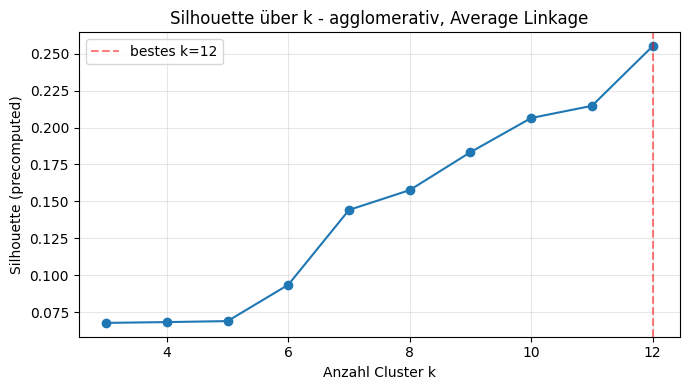

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(list(scores.keys()), list(scores.values()), marker="o")
ax.axvline(best_k, color="red", linestyle="--", alpha=0.5, label=f"bestes k={best_k}")
ax.set_xlabel("Anzahl Cluster k")
ax.set_ylabel("Silhouette (precomputed)")
ax.set_title("Silhouette über k - agglomerativ, Average Linkage")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### HDBSCAN als Vergleich

HDBSCAN benötigt kein `k` - wir geben nur eine minimale Clustergröße vor. Punkte, die nicht passen, bekommen das Label `-1` (Rauschen), das wir später für die Ausreißererkennung wiederverwenden.

In [6]:
try:
    import hdbscan
    hdb_labels = hdbscan.HDBSCAN(
        metric="precomputed", min_cluster_size=15, min_samples=5
    ).fit_predict(D.astype(np.float64))
    n_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
    n_noise = int((hdb_labels == -1).sum())
    print(f"HDBSCAN: {n_clusters} Cluster, {n_noise} Rauschpunkte")
except ImportError:
    hdb_labels = None
    print("hdbscan nicht installiert - überspringe (pip install hdbscan)")

HDBSCAN: 14 Cluster, 367 Rauschpunkte


### Was steckt in jedem Cluster?

Eine kurze Übersicht: Clustergröße, durchschnittliche Stat-Summe und die häufigsten Typen. Das ist die Grundlage für die Einfärbung der 2D-Plots.

In [7]:
df_c = df.copy()
df_c["cluster"] = labels
df_c["stat_total"] = df_c[STAT_COLS].sum(axis=1)

rows = []
for c, sub in df_c.groupby("cluster"):
    top_types = sub[TYPE_COLS].sum().sort_values(ascending=False).head(3)
    rows.append({
        "cluster": c,
        "groesse": len(sub),
        "avg_stat_summe": round(sub["stat_total"].mean(), 1),
        "top_typen": ", ".join(t.replace("type_", "") for t in top_types.index),
        "beispiel": ", ".join(sub["name"].head(3).tolist()),
    })
pd.DataFrame(rows)

,cluster,groesse,avg_stat_summe,top_typen,beispiel
0,0,327,402.7,"grass, flying, fire","Bulbasaur, Ivysaur, Venusaur"
1,1,72,426.9,"ground, rock, steel","Sandshrew, Sandslash, Diglett"
2,2,135,416.0,"water, ice, rock","Squirtle, Wartortle, Blastoise"
3,3,36,411.7,"fairy, water, dark","Clefairy, Clefable, Jigglypuff"
4,4,41,502.4,"dragon, flying, ghost","Dratini, Dragonair, Dragonite"
5,5,67,450.1,"psychic, fairy, grass","Abra, Kadabra, Alakazam"
6,6,69,407.1,"fire, psychic, steel","Rattata, Raticate, Meowth"
7,7,1,505.0,"rock, bug, fire",Shuckle
8,8,49,434.0,"electric, bug, steel","Pikachu, Raichu, Magnemite"
9,9,50,450.6,"fighting, dark, grass","Mankey, Primeape, Poliwrath"


## Aufgabe 3 - 2D-Visualisierung mit tSNE und UMAP

Beide Verfahren akzeptieren eine vorberechnete Distanzmatrix, deshalb können wir `D` direkt übergeben. Ziel der Plots: **visuell prüfen, ob die Cluster-Labels echter Struktur entsprechen** oder ob das Embedding eine andere Geschichte erzählt.

Parameter-Hinweise:
- **tSNE** `perplexity=30` ist ein sinnvoller Default für ~900 Punkte; niedrigere Werte zerfasern, höhere verschmieren.
- **UMAP** `n_neighbors=20`, `min_dist=0.1` erzeugt kompaktere, deutlicher abgesetzte Cluster als die Defaults.

In [8]:
tsne_emb = TSNE(
    n_components=2, metric="precomputed", init="random",
    perplexity=30, random_state=42,
).fit_transform(D)

try:
    import umap
    umap_emb = umap.UMAP(
        n_components=2, metric="precomputed",
        n_neighbors=20, min_dist=0.1, random_state=42,
    ).fit_transform(D)
except ImportError:
    umap_emb = None
    print("umap-learn nicht installiert - überspringe UMAP (pip install umap-learn)")

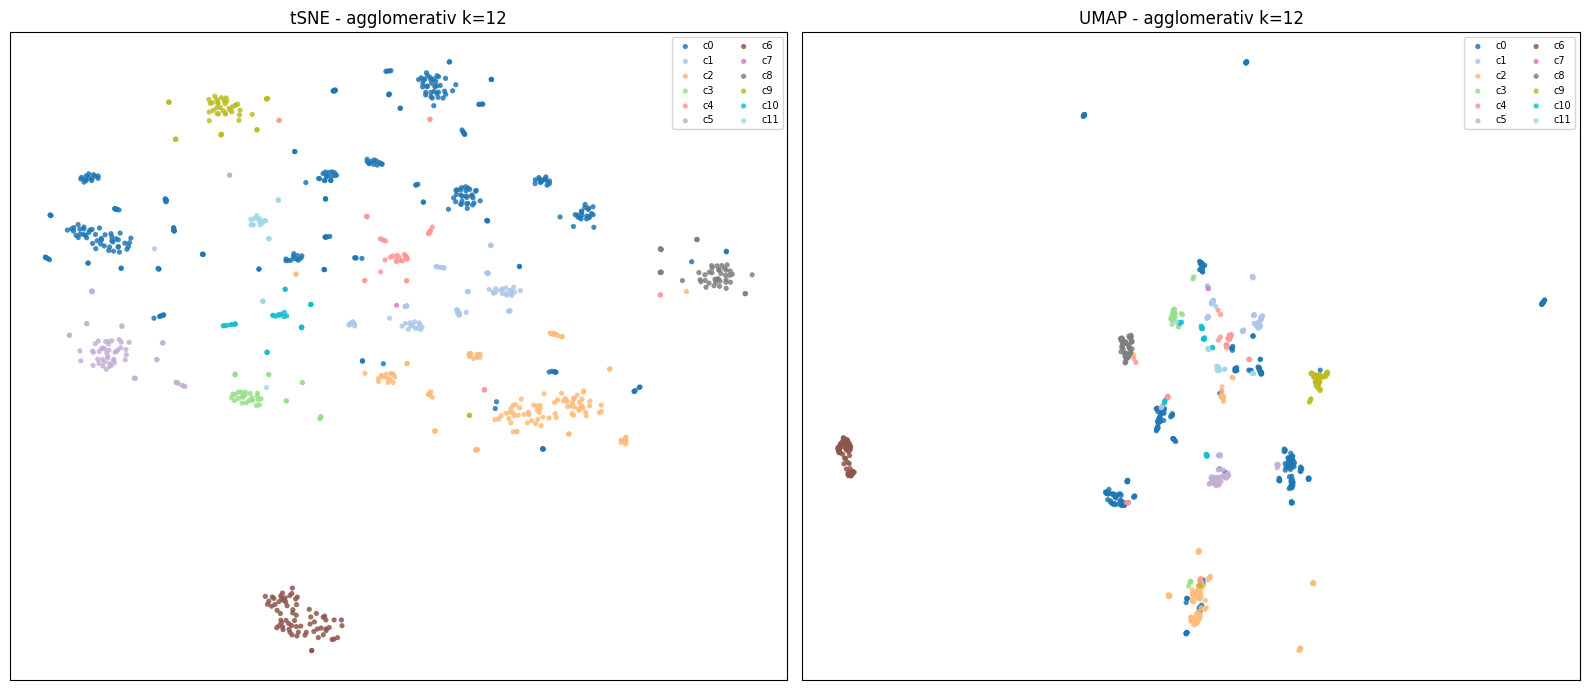

In [9]:
def scatter(ax, emb, labels, title, names=None, outliers=None):
    labels = np.asarray(labels)
    uniq = sorted(set(labels))
    cmap = plt.get_cmap("tab20", max(len(uniq), 1))
    for i, lab in enumerate(uniq):
        mask = labels == lab
        color = "lightgrey" if lab == -1 else cmap(i)
        name = "Rauschen" if lab == -1 else f"c{lab}"
        ax.scatter(emb[mask, 0], emb[mask, 1], s=14, c=[color],
                   label=name, alpha=0.85, edgecolors="none")
    if outliers is not None:
        ax.scatter(emb[outliers, 0], emb[outliers, 1], s=70,
                   facecolors="none", edgecolors="red", linewidths=1.5,
                   label="Ausreißer")
        if names is not None:
            for i in outliers:
                ax.annotate(names[i], (emb[i, 0], emb[i, 1]),
                            fontsize=7, alpha=0.7)
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])
    ax.legend(loc="best", fontsize=7, ncol=2)

n_panels = 2 if umap_emb is not None else 1
fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7))
if n_panels == 1:
    axes = [axes]
scatter(axes[0], tsne_emb, labels, f"tSNE - agglomerativ k={best_k}")
if umap_emb is not None:
    scatter(axes[1], umap_emb, labels, f"UMAP - agglomerativ k={best_k}")
plt.tight_layout()
plt.savefig(OUT / "embeddings_agglom.png", dpi=130)
plt.show()

Dieselben Embeddings, diesmal eingefärbt nach **HDBSCAN**-Labels (Rauschen ist grau). Im Vergleich zu den agglomerativen Plots oben findet HDBSCAN tendenziell weniger, dichtere Gruppen und lässt einen langen Schweif ungewöhnlicher Pokemon als Rauschen übrig.

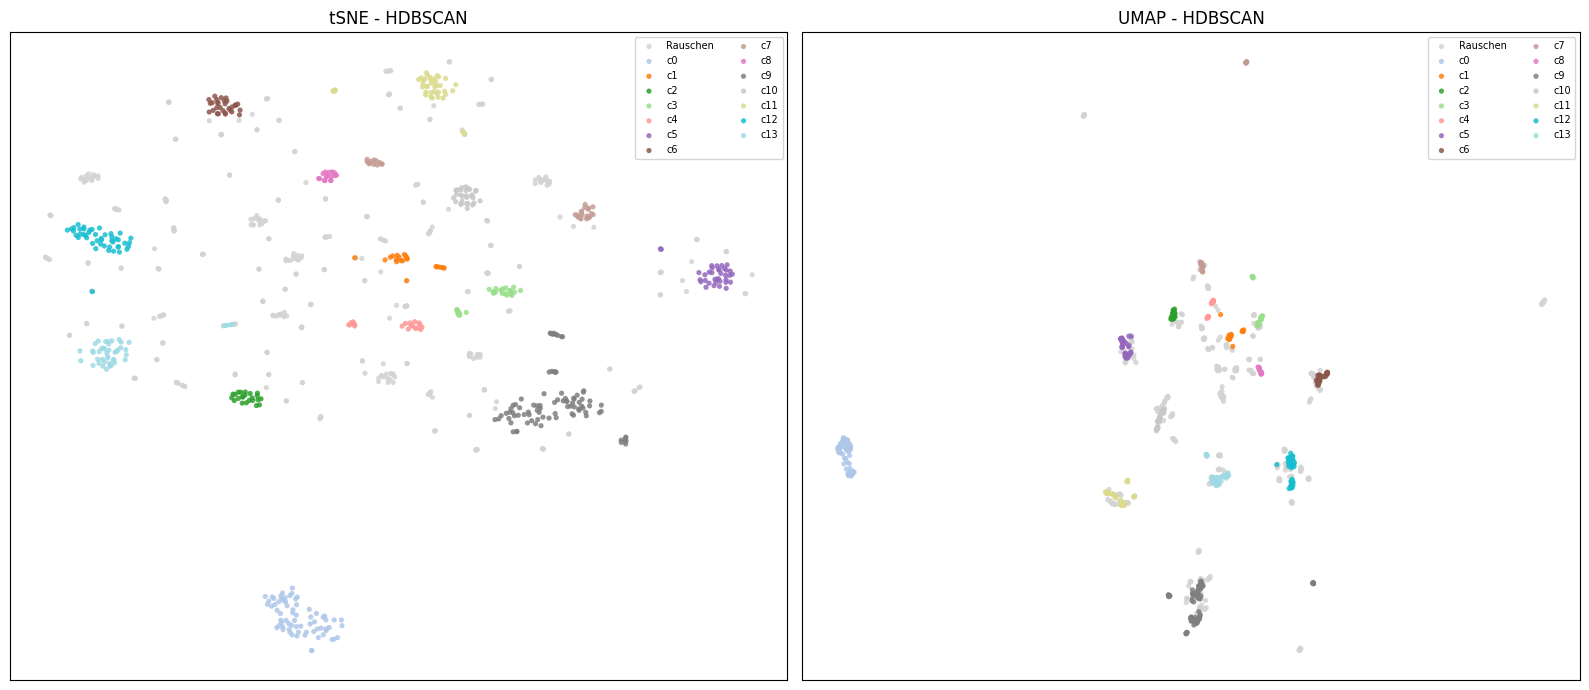

In [10]:
if hdb_labels is not None:
    fig, axes = plt.subplots(1, n_panels, figsize=(8 * n_panels, 7))
    if n_panels == 1:
        axes = [axes]
    scatter(axes[0], tsne_emb, hdb_labels, "tSNE - HDBSCAN")
    if umap_emb is not None:
        scatter(axes[1], umap_emb, hdb_labels, "UMAP - HDBSCAN")
    plt.tight_layout()
    plt.savefig(OUT / "embeddings_hdbscan.png", dpi=130)
    plt.show()

## Aufgabe 4 - Ausreißererkennung

Wir verwenden drei komplementäre Verfahren und suchen nach **Konsens**:

- **Local Outlier Factor (LOF)** auf der vorberechneten Distanz - markiert Punkte, deren lokale Dichte deutlich unter der ihrer Nachbarn liegt. Gut darin, Pokemon zu finden, die in dünnen Regionen der Metrik liegen.
- **Isolation Forest** auf den Distanzzeilen - markiert Punkte mit ungewöhnlichem "Distanz-Fingerprint". Eher globale Sicht.
- **HDBSCAN-Rauschen** (aus Aufgabe 2) - Punkte, die überhaupt keinem Cluster zugeordnet werden konnten.

Ein Pokemon, das von zwei oder drei Methoden markiert wird, ist ein starker Ausreißerkandidat.

In [11]:
contamination = 0.03  # ~3 % erwartete Ausreißer

lof_mask = LocalOutlierFactor(
    metric="precomputed", n_neighbors=20, contamination=contamination
).fit_predict(D) == -1

iso_mask = IsolationForest(
    contamination=contamination, random_state=42
).fit_predict(D) == -1

print(f"LOF markiert            : {lof_mask.sum()}")
print(f"Isolation Forest markiert: {iso_mask.sum()}")
print(f"LOF UND ISO einig       : {(lof_mask & iso_mask).sum()}")
if hdb_labels is not None:
    print(f"HDBSCAN-Rauschen        : {(hdb_labels == -1).sum()}")

LOF markiert            : 27
Isolation Forest markiert: 27
LOF UND ISO einig       : 3
HDBSCAN-Rauschen        : 367


In [12]:
outlier_idx = np.where(lof_mask | iso_mask)[0]
rows = []
for i in outlier_idx:
    flags = []
    if lof_mask[i]: flags.append("LOF")
    if iso_mask[i]: flags.append("ISO")
    if hdb_labels is not None and hdb_labels[i] == -1: flags.append("HDB")
    rows.append({
        "name": df.loc[i, "name"],
        "stat_summe": int(df.loc[i, STAT_COLS].sum()),
        "groesse_m": df.loc[i, "height_m"],
        "gewicht_kg": df.loc[i, "weight_kg"],
        "typen": ",".join(t.replace("type_", "") for t in TYPE_COLS if df.loc[i, t] == 1),
        "flags": "+".join(flags),
        "n_flags": len(flags),
    })
outliers_df = pd.DataFrame(rows).sort_values(["n_flags", "name"], ascending=[False, True])
outliers_df.head(20)

,name,stat_summe,groesse_m,gewicht_kg,typen,flags,n_flags
44,Kartana,570,0.3,0.1,"grass,steel",LOF+ISO+HDB,3
41,Araquanid,454,1.8,82.0,"water,bug",LOF+HDB,2
37,Avalugg,514,2.0,505.0,ice,ISO+HDB,2
11,Blissey,540,1.5,46.8,,LOF+ISO,2
43,Bruxish,475,0.9,19.0,"water,psychic",LOF+HDB,2
18,Carvanha,305,0.8,20.8,"water,dark",LOF+HDB,2
4,Chansey,450,1.1,34.6,,LOF+ISO,2
5,Chinchou,330,0.5,12.0,"water,electric",LOF+HDB,2
20,Crawdaunt,468,1.1,32.8,"water,dark",LOF+HDB,2
28,Empoleon,530,1.7,84.5,"water,steel",LOF+HDB,2


### Ausreißer im 2D-Embedding

Wir heben die markierten Pokemon in den tSNE-/UMAP-Plots hervor. Sie sollten überwiegend an den Rändern von Clustern oder in deren Lücken liegen.

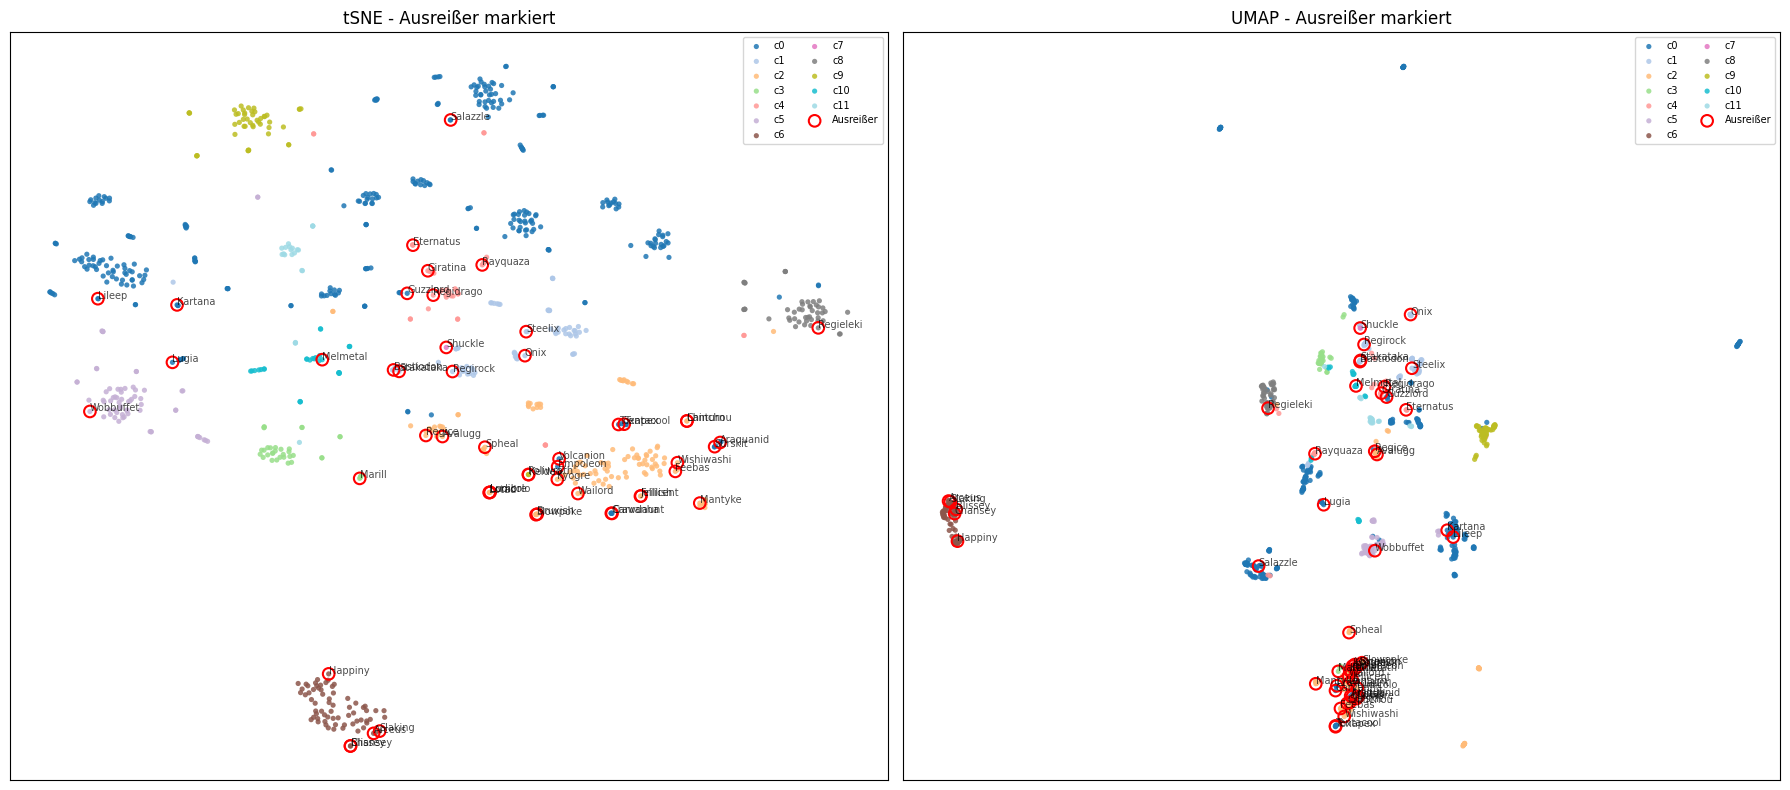

In [13]:
names = df["name"].tolist()
fig, axes = plt.subplots(1, n_panels, figsize=(9 * n_panels, 8))
if n_panels == 1:
    axes = [axes]
scatter(axes[0], tsne_emb, labels, "tSNE - Ausreißer markiert",
        names=names, outliers=outlier_idx)
if umap_emb is not None:
    scatter(axes[1], umap_emb, labels, "UMAP - Ausreißer markiert",
            names=names, outliers=outlier_idx)
plt.tight_layout()
plt.savefig(OUT / "embeddings_outliers.png", dpi=130)
plt.show()

### Was macht sie zu Ausreißern?

In der Konsensliste tauchen vier wiederkehrende Muster auf:

- **Ungewöhnliche Stat-Profile** - Chansey/Heiteira haben enorme HP, aber kaum Defensiv-Werte; Pottrott hat extreme Verteidigung und kaum Offensive. Solche Profile passen in kein "normales" Stat-Schema.
- **Ungewöhnliche Typ-Kombinationen** - Water+Electric (Lanturn), Water+Fighting (Quappo), Bug+Rock (Pottrott) sind seltene Kombinationen weit ab von den dichten Typ-Clustern.
- **Ungewöhnliche Größe** - sehr schwere Pokemon (Stahlos mit ~400 kg) oder sehr kleine landen in den Tails der Größenverteilung.
- **Legendäre** - hohe Stat-Summen plus seltene Typ-Kombinationen (z. B. Lugia: Psychic+Flying, Stat-Summe 680).

Alle vier Kategorien sind genau die Art von "anders", die eine Ausreißererkennung finden soll.

## Aufgabe 5 - Diskussion und Reflexion

### Was gut funktioniert hat

- **tSNE-Visualisierung war das Highlight des Projekts.** Mit `perplexity=30` und der vorberechneten Distanzmatrix entstand fast ohne Tuning ein Ergebnis, das die Stat-/Typ-Struktur klar abbildet - hochstatige Legendäre am Rand, frühe Entwicklungsstufen kompakt zusammen, Typ-Familien als sichtbare Sub-Blobs. Die Implementierung war ein Dreizeiler mit `sklearn.manifold.TSNE`, und der Output hat sofort Sinn ergeben. Das ist genau der Punkt, an dem man merkt, dass die vorgelagerte Distanzfunktion gut gewählt war: wenn die Projektion Struktur zeigt, hat die Metrik bereits die richtige getroffen.
- Der blockweise Aufbau der Distanz (Stats + Types + Size) war ebenfalls hilfreich, weil sich die Beiträge einzeln anschauen und gewichten lassen.
- Mehrere Ausreißermethoden gegeneinander zu prüfen, lieferte deutlich verlässlichere Kandidaten als jede Methode allein. Die Konsensliste liest sich exakt wie die Pokemon, die ein Fan intuitiv als "komisch" benennen würde.

### Herausforderungen

- **Die Distanzfunktion war der schwierigste Teil.** Drei sehr unterschiedliche Datentypen (kontinuierliche Stats, kategoriale Typen-Sets, heavy-tailed Größenwerte) auf eine einzige skalare Distanz abzubilden, ist nicht objektiv lösbar - jede Wahl ist eine Designentscheidung. Konkrete Stolpersteine:
  - **Block-Gewichte sind subjektiv.** Die Wahl `(0.5, 0.4, 0.1)` ist plausibel, aber jede andere Aufteilung verändert die Cluster spürbar. Ohne ein objektives Optimierungsziel (z. B. Type-Reinheit) bleibt das eine begründete, aber nicht beweisbare Wahl.
  - **Jaccard ist auf One-Hot-Type-Vektoren grob.** Da die meisten Pokemon nur 1-2 Typen haben, kann die Jaccard-Distanz nur wenige diskrete Werte annehmen. Das musste durch Untergewichtung gegenüber Stats kompensiert werden, sonst entstand pro Typ ein riesiger Blob.
  - **Heavy Tails bei Größe/Gewicht.** Ohne `log1p` hat Wailord allein die Größendistanz dominiert. Erst die Log-Skalierung hat das Problem entschärft - das musste durch Ausprobieren herausgefunden werden.
- Der Silhouettenkoeffizient stieg monoton mit `k` - "bestes k" bedeutet hier nur "am wenigsten schlecht unter den getesteten Werten". Das deutet auf ein Kontinuum hin und ist eine grundsätzliche Limitation der Datenlage, nicht der Methode.
- Dass HDBSCAN ~40 % der Punkte als Rauschen markiert, bestätigt: die Dichte im Raum ist sehr ungleichmäßig.

### Mit mehr Zeit

- **Thumbnails verwenden** - die Bilder durch ein vortrainiertes CNN (z. B. CLIP oder einen kleinen ResNet) schicken und ein Bild-Embedding als vierten Distanzblock hinzufügen. Damit ließe sich die visuelle Ähnlichkeit (Farbe, Form, Pose) zusätzlich abbilden.
- **Block-Gewichte systematisch tunen** - per Grid Search gegen eine downstream-Metrik wie Typ-Reinheit der Cluster oder Wiederfindung bekannter Evolutionslinien. Das würde die größte subjektive Schwachstelle der aktuellen Lösung adressieren.
- **Mehr Clusterverfahren vergleichen** - spektrales Clustering, OPTICS und k-Medoids gegen die aktuelle Wahl benchmarken und Stabilität über mehrere Random Seeds berichten.
- **Analyse pro Generation** - separat innerhalb und über Generationen clustern, um zu sehen, ob der Power-Creep der Hauptserie sich als Drift im Embedding zeigt.
- **Interaktive Visualisierung** - die tSNE-/UMAP-Plots als interaktives Bokeh- oder Plotly-Dashboard mit Hover-Thumbnails wären didaktisch deutlich wertvoller als statische PNGs.